# 04 - Classification
Loan Default Prediction Capstone

Goal: train classifiers to predict `Default`, comparing Model A (original features only) vs Model B (original features + Cluster_ID), across multiple classifiers. Tune with GridSearchCV, evaluate with accuracy/precision/recall/F1, and use SHAP for per-prediction explainability on the best-performing model — regardless of which classifier that turns out to be.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import joblib
import os

df = pd.read_csv('../data/preprocessed_data_with_clusters.csv')
df.shape

(255347, 26)

## 2. Check Class Balance
Confirms whether `Default` is imbalanced — shapes which metrics we should trust most (precision/recall/F1 over raw accuracy if imbalanced).

In [2]:
print(df['Default'].value_counts())
print(df['Default'].value_counts(normalize=True) * 100)

# Automatically decide the scoring metric based on class balance, rather than hardcoding it
class_balance = df['Default'].value_counts(normalize=True)
minority_pct = class_balance.min() * 100

print(f"\nMinority class percentage: {minority_pct:.2f}%")

if minority_pct < 40:
    scoring_metric = 'f1'
    print("Class imbalance detected (minority class < 40%) — using F1 as the scoring metric.")
else:
    scoring_metric = 'accuracy'
    print("Classes reasonably balanced (minority class >= 40%) — using accuracy as the scoring metric.")


Default
0    225694
1     29653
Name: count, dtype: int64
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

Minority class percentage: 11.61%
Class imbalance detected (minority class < 40%) — using F1 as the scoring metric.


## 3. Build Model A and Model B Feature Sets
Model A = original features only. Model B = original features + Cluster_ID. Same target, same split, for a fair comparison.

In [3]:
target_col = 'Default'

features_A = [col for col in df.columns if col not in ['Default', 'Cluster_ID']]
features_B = features_A + ['Cluster_ID']

X_A = df[features_A]
X_B = df[features_B]
y = df[target_col]

print("Model A features:", len(features_A))
print("Model B features:", len(features_B))

Model A features: 24
Model B features: 25


## 4. Train/Test Split
Same split indices used for both Model A and Model B, so the comparison is fair — stratified on the target since the classes are imbalanced.

In [4]:
X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A, y, test_size=0.2, random_state=42, stratify=y)

X_B_train, X_B_test, _, _ = train_test_split(
    X_B, y, test_size=0.2, random_state=42, stratify=y)

print(X_A_train.shape, X_A_test.shape)
print(X_B_train.shape, X_B_test.shape)

(204277, 24) (51070, 24)
(204277, 25) (51070, 25)


## 5. Define Models and Hyperparameter Grids
Three classifiers compared: Logistic Regression (interpretable baseline), Decision Tree (threshold-based, roadmap-aligned), Random Forest (bonus, likely best raw performance). `class_weight='balanced'` included given the imbalance confirmed above.

In [5]:
model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    },
    
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 10]
        }
    }
}

## 6. Train, Tune, and Evaluate — Model A (No Cluster_ID)
GridSearchCV run per classifier, scored on F1 (more meaningful than accuracy given class imbalance).

In [6]:
results_A = {}
fitted_models_A = {}

for name, config in model_configs.items():
    print(f"Tuning {name} (Model A)...")
    grid = GridSearchCV(config['model'], config['params'], cv=3, scoring=scoring_metric, n_jobs=-1)
    grid.fit(X_A_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_A_test)

    results_A[name] = {
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    }
    fitted_models_A[name] = best_model
    print(f"  Best params: {grid.best_params_}")
    print(f"  F1: {results_A[name]['F1']:.4f}\n")

Tuning Logistic Regression (Model A)...


c:\Users\Rayaan\Downloads\Capstone Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  F1: 0.3342

Tuning Random Forest (Model A)...
  Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
  F1: 0.3464



## 7. Train, Tune, and Evaluate — Model B (With Cluster_ID)

In [7]:
results_B = {}
fitted_models_B = {}

for name, config in model_configs.items():
    print(f"Tuning {name} (Model B)...")
    # fresh model instance so Model A's fitted state isn't reused
    model_instance = type(config['model'])(**config['model'].get_params())
    grid = GridSearchCV(model_instance, config['params'], cv=3, scoring=scoring_metric, n_jobs=-1)
    grid.fit(X_B_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_B_test)

    results_B[name] = {
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    }
    fitted_models_B[name] = best_model
    print(f"  Best params: {grid.best_params_}")
    print(f"  F1: {results_B[name]['F1']:.4f}\n")

Tuning Logistic Regression (Model B)...


c:\Users\Rayaan\Downloads\Capstone Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
  F1: 0.3344

Tuning Random Forest (Model B)...
  Best params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}
  F1: 0.3527



## 8. Comparison Table — Model A vs Model B, All Classifiers
This is the core capstone finding: does adding Cluster_ID as a feature improve each classifier's performance?

In [8]:
comparison_rows = []
for name in model_configs.keys():
    comparison_rows.append({
        'Model': name, 'Variant': 'A (no cluster)',
        'Accuracy': results_A[name]['Accuracy'], 'Precision': results_A[name]['Precision'],
        'Recall': results_A[name]['Recall'], 'F1': results_A[name]['F1']
    })
    comparison_rows.append({
        'Model': name, 'Variant': 'B (with cluster)',
        'Accuracy': results_B[name]['Accuracy'], 'Precision': results_B[name]['Precision'],
        'Recall': results_B[name]['Recall'], 'F1': results_B[name]['F1']
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Variant,Accuracy,Precision,Recall,F1
0,Logistic Regression,A (no cluster),0.676307,0.219517,0.699376,0.334152
1,Logistic Regression,B (with cluster),0.676797,0.219749,0.699039,0.334382
2,Random Forest,A (no cluster),0.708772,0.234249,0.664475,0.346385
3,Random Forest,B (with cluster),0.838614,0.330099,0.378520,0.352655


<Figure size 1200x600 with 0 Axes>

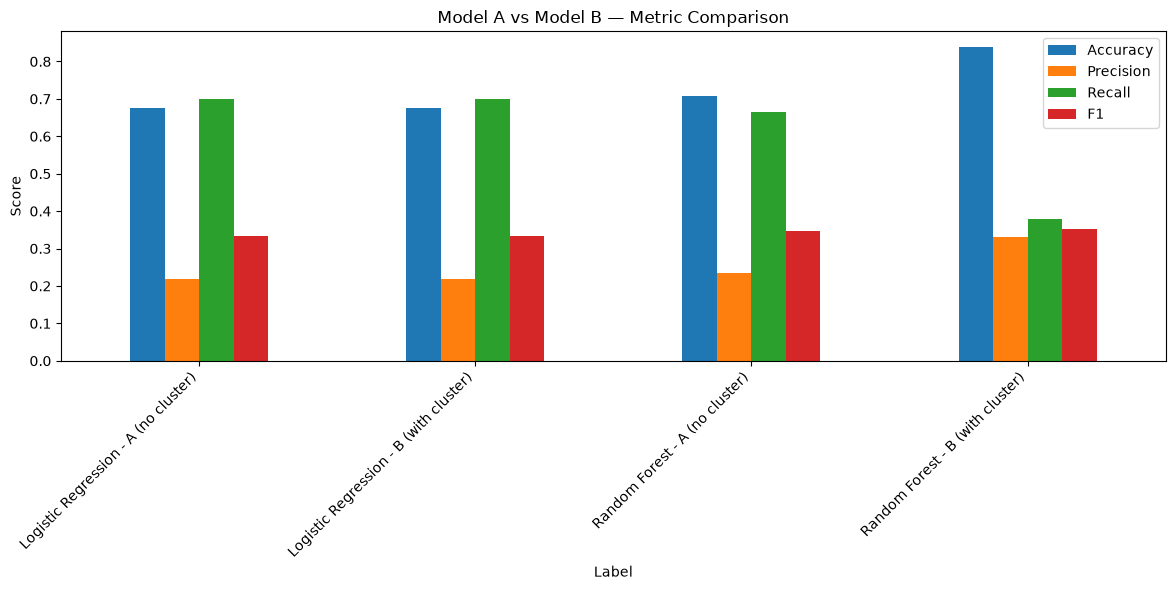

In [9]:
comparison_df['Label'] = comparison_df['Model'] + ' - ' + comparison_df['Variant']

plt.figure(figsize=(12,6))
comparison_df.set_index('Label')[['Accuracy','Precision','Recall','F1']].plot(kind='bar', figsize=(12,6))
plt.title('Model A vs Model B — Metric Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Confusion Matrices
Quick visual check on all model variants — especially useful given the class imbalance, to see how each model handles the minority (Default=1) class specifically.

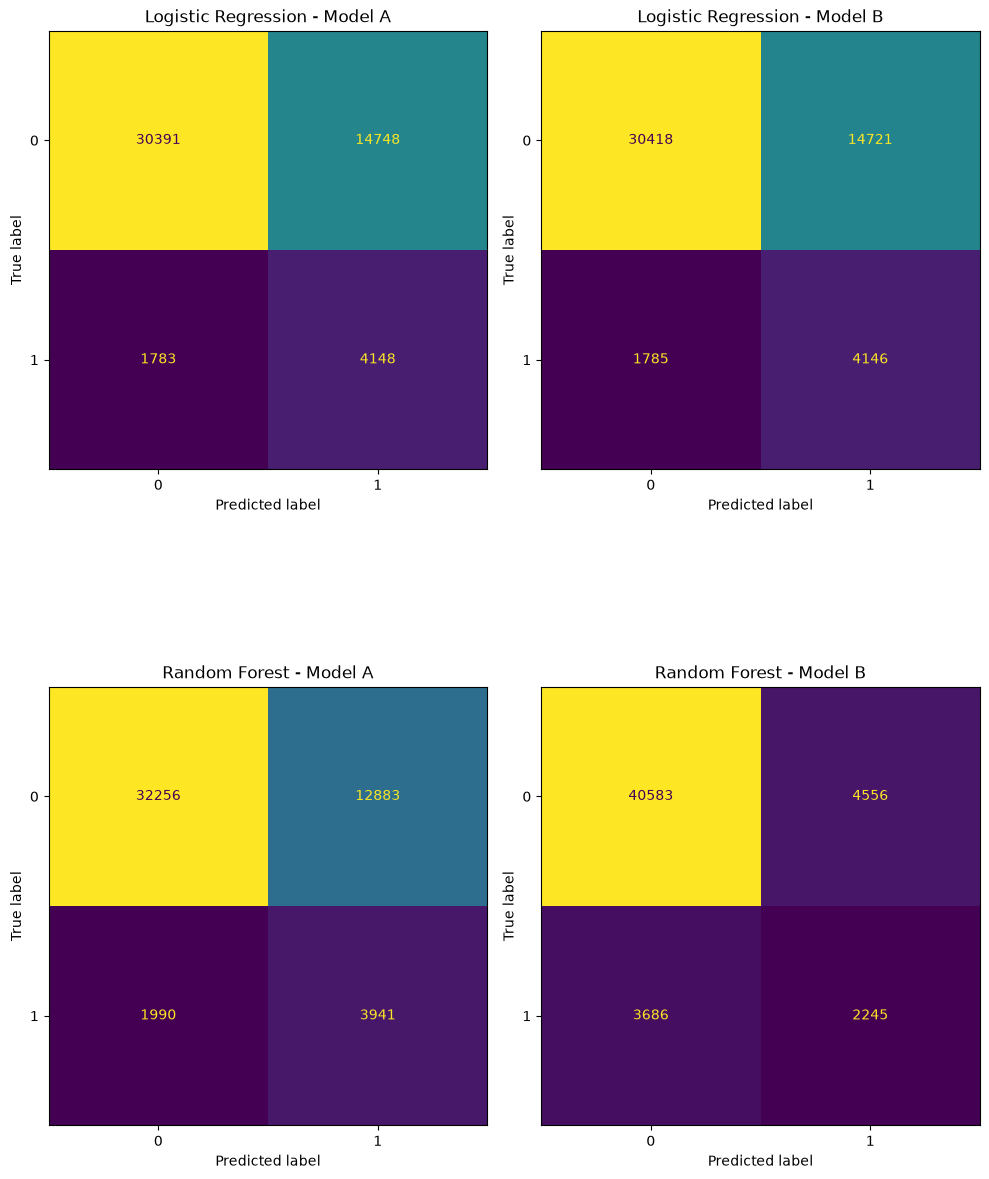

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10,14))

for i, name in enumerate(model_configs.keys()):
    preds_A = fitted_models_A[name].predict(X_A_test)
    preds_B = fitted_models_B[name].predict(X_B_test)

    ConfusionMatrixDisplay.from_predictions(y_test, preds_A, ax=axes[i,0], colorbar=False, values_format='d')
    axes[i,0].set_title(f'{name} - Model A')

    ConfusionMatrixDisplay.from_predictions(y_test, preds_B, ax=axes[i,1], colorbar=False, values_format='d')
    axes[i,1].set_title(f'{name} - Model B')

plt.tight_layout()
plt.show()

## 10. Select Best Model Overall
Based on F1-score across all variants (not just accuracy, given the imbalance) — this becomes the model deployed in Streamlit, regardless of which classifier or variant it is.

In [11]:
metric_col = scoring_metric.capitalize() if scoring_metric != 'f1' else 'F1'
best_row = comparison_df.loc[comparison_df[metric_col].idxmax()]
print("Best performing model:")
print(best_row)

best_model_name = best_row['Model']
best_variant = best_row['Variant']
best_model_obj = fitted_models_B[best_model_name] if 'B' in best_variant else fitted_models_A[best_model_name]
best_X_test = X_B_test if 'B' in best_variant else X_A_test
best_X_train = X_B_train if 'B' in best_variant else X_A_train

Best performing model:
Model                           Random Forest
Variant                      B (with cluster)
Accuracy                             0.838614
Precision                            0.330099
Recall                                0.37852
F1                                   0.352655
Label        Random Forest - B (with cluster)
Name: 3, dtype: object


## 11. SHAP — Per-Prediction Explainability
Works regardless of which model won (tree-based or linear), which is why SHAP replaces the earlier plan of only using raw Logistic Regression coefficients — we're no longer forced to deploy a specific model purely for interpretability reasons.

Computed on a sample, not the full test set, since SHAP computation can be expensive at scale.

Best model selected: Random Forest - B (with cluster)
SHAP computation took 372.25 seconds for 200 rows
SHAP values shape: (200, 25) | Sample shape: (200, 25)


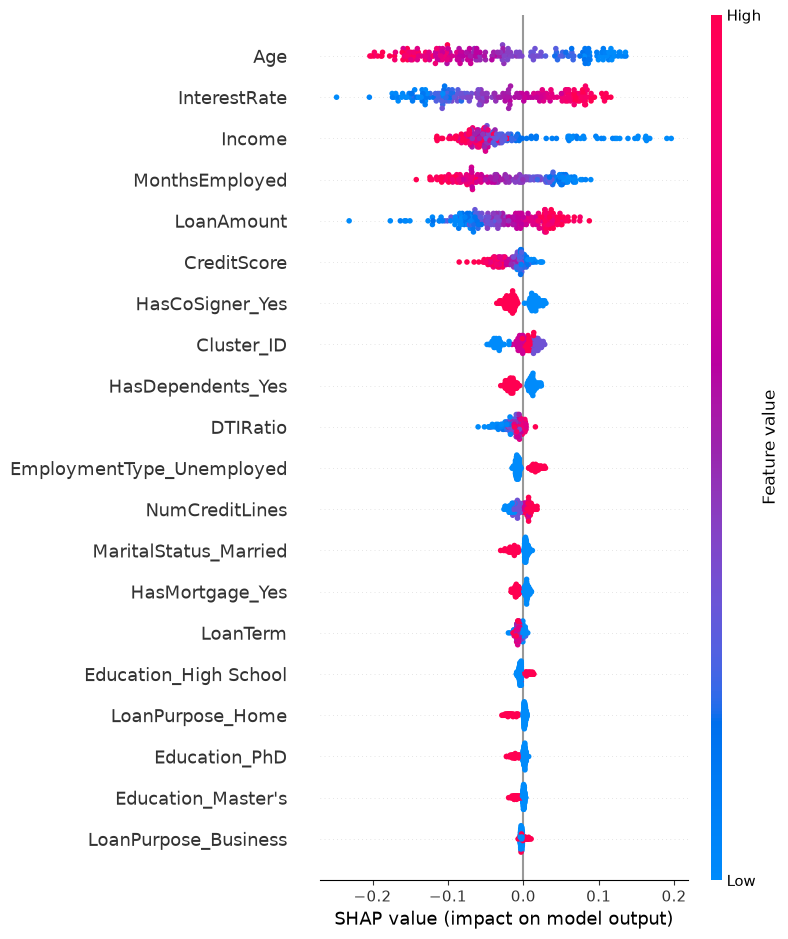

In [12]:
import shap
import time

# Print winning model to confirm before building the explainer
print("Best model selected:", best_model_name, "-", best_variant)

shap_sample = best_X_test.sample(n=min(200, len(best_X_test)), random_state=42)

start = time.time()

if best_model_name in ['Random Forest', 'Decision Tree']:
    explainer = shap.TreeExplainer(best_model_obj, feature_perturbation='tree_path_dependent')
    shap_values = explainer.shap_values(shap_sample, check_additivity=False)

    # Handle different SHAP output shapes across versions:
    # - list of arrays [class_0, class_1] (older SHAP)
    # - 3D array (rows, features, classes) (newer SHAP)
    # - 2D array (rows, features) (already binary-only)
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1]
    else:
        shap_values = np.array(shap_values)
        if shap_values.ndim == 3:
            shap_values_to_plot = shap_values[:, :, 1]   # class 1 (Default) only
        else:
            shap_values_to_plot = shap_values
else:
    background_sample = best_X_train.sample(n=200, random_state=42)
    explainer = shap.LinearExplainer(best_model_obj, background_sample)
    shap_values_to_plot = explainer.shap_values(shap_sample)

print(f"SHAP computation took {time.time() - start:.2f} seconds for {len(shap_sample)} rows")
print("SHAP values shape:", np.array(shap_values_to_plot).shape, "| Sample shape:", shap_sample.shape)

shap.summary_plot(shap_values_to_plot, shap_sample, show=True)

In [18]:
import joblib

# Precompute the SHAP summary values once and save to disk,
# so the Streamlit app never has to recompute this on startup.
shap_summary_sample = best_X_test.sample(n=min(200, len(best_X_test)), random_state=42)

if best_model_name in ['Random Forest', 'Decision Tree']:
    shap_summary_values = explainer.shap_values(shap_summary_sample, check_additivity=False)
    shap_summary_values = np.array(shap_summary_values)
    if shap_summary_values.ndim == 3:
        shap_summary_values = shap_summary_values[:, :, 1]
else:
    shap_summary_values = explainer.shap_values(shap_summary_sample)

joblib.dump(shap_summary_values, '../models/shap_summary_values.pkl')
shap_summary_sample.to_csv('../data/shap_summary_sample.csv', index=False)

print("Saved: models/shap_summary_values.pkl")
print("Saved: data/shap_summary_sample.csv")

Saved: models/shap_summary_values.pkl
Saved: data/shap_summary_sample.csv


## 12. SHAP — Single Prediction Example
This is the pattern the Streamlit app will reuse: explain one specific input's prediction, feature by feature.

In [19]:
single_input = shap_sample.iloc[[0]]

if best_model_name in ['Random Forest', 'Decision Tree']:
    single_shap = explainer.shap_values(single_input, check_additivity=False)

    # Handle multiple possible SHAP output shapes across versions:
    # - list of arrays [class_0, class_1] (older SHAP)
    # - 3D array (rows, features, classes) (newer SHAP)
    # - 2D array (rows, features) (already binary-only output)
    if isinstance(single_shap, list):
        single_shap_vals = np.array(single_shap[1][0]).flatten()
        exp_val = explainer.expected_value
        base_value = exp_val[1] if isinstance(exp_val, (list, np.ndarray)) else exp_val
    else:
        single_shap = np.array(single_shap)
        if single_shap.ndim == 3:
            # (rows, features, classes) -> take row 0, class 1
            single_shap_vals = single_shap[0, :, 1].flatten()
        else:
            # (rows, features)
            single_shap_vals = single_shap[0].flatten()
        exp_val = explainer.expected_value
        base_value = exp_val[1] if isinstance(exp_val, (list, np.ndarray)) and len(np.atleast_1d(exp_val)) > 1 else exp_val
else:
    single_shap_vals = np.array(explainer.shap_values(single_input)[0]).flatten()
    base_value = explainer.expected_value

# Safety check: lengths must match before building the dataframe
assert len(single_shap_vals) == len(single_input.columns), (
    f"Mismatch: {len(single_shap_vals)} SHAP values vs {len(single_input.columns)} features"
)

contribution_df = pd.DataFrame({
    'Feature': single_input.columns,
    'Value': single_input.values[0],
    'SHAP Contribution': single_shap_vals
}).sort_values(by='SHAP Contribution', key=abs, ascending=False)

print("Base value (average model output):", base_value)
print(contribution_df.to_string(index=False))

Base value (average model output): 0.4999781913773945
                     Feature     Value  SHAP Contribution
                InterestRate -0.896984          -0.123595
                  LoanAmount -0.862922          -0.053538
              MonthsEmployed -1.256865           0.053467
                      Income  0.827625          -0.053044
           HasDependents_Yes     False           0.023643
             HasCoSigner_Yes     False           0.023191
                         Age -0.366793          -0.014130
   EmploymentType_Unemployed     False          -0.013197
                    DTIRatio  1.688006          -0.012073
                    LoanTerm  0.705634          -0.008858
              NumCreditLines -0.448549          -0.008555
                  Cluster_ID         3           0.006849
       LoanPurpose_Education      True          -0.006406
       MaritalStatus_Married     False           0.005016
                 CreditScore -0.813477           0.004957
             HasMo

## 13. Save Final Models
Saves the best model, plus both Model A and Model B versions of the winning classifier type, for Streamlit's side-by-side comparison feature. Also saves the SHAP explainer for reuse in the app.

In [20]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model_obj, '../models/best_model.pkl')
joblib.dump(fitted_models_A[best_model_name], '../models/model_a.pkl')
joblib.dump(fitted_models_B[best_model_name], '../models/model_b.pkl')
joblib.dump(explainer, '../models/shap_explainer.pkl')
joblib.dump(features_A, '../models/features_a.pkl')
joblib.dump(features_B, '../models/features_b.pkl')

comparison_df.to_csv('../data/model_comparison.csv', index=False)

print("Saved: models/best_model.pkl")
print("Saved: models/model_a.pkl, model_b.pkl")
print("Saved: models/shap_explainer.pkl")
print("Saved: data/model_comparison.csv")
print(f"\nBest model: {best_model_name} ({best_variant})")

Saved: models/best_model.pkl
Saved: models/model_a.pkl, model_b.pkl
Saved: models/shap_explainer.pkl
Saved: data/model_comparison.csv

Best model: Random Forest (B (with cluster))


## 14. Notes / Findings
(Fill in after running: which classifier + variant won overall, how much Cluster_ID helped or didn't for each classifier, and what SHAP revealed about which features matter most for the deployed model.)